<center>
  <h1 style="color: #4a90e2;">Space Titanic</h1>
  <h2 style="color: #50e3c2;">🚀✨ 0.814 🔧『Optuna XGB』| Space Titanic</h2>
  <h3 style="color: #7f8c8d;">If you find my notebook helpful, support with one upvote, thank you</h3>
  <h4 style="color: #bdc3c7;">Created by Mr.Tao 10/11/2023 👍</h4>
</center>


# <span style="color: #2E8B57;">📁 Description</span>

## <span style="color: #4682B4;">📣  Recommended Competition</span>

We highly recommend Titanic - Machine Learning from Disaster to get familiar with the basics of machine learning and Kaggle competitions.

Welcome to the year 2912, where your data science skills are needed to solve a cosmic mystery. We've received a transmission from four lightyears away and things aren't looking good.

The Spaceship Titanic was an interstellar passenger liner launched a month ago. With almost 13,000 passengers on board, the vessel set out on its maiden voyage transporting emigrants from our solar system to three newly habitable exoplanets orbiting nearby stars.

While rounding Alpha Centauri en route to its first destination—the torrid 55 Cancri E—the unwary Spaceship Titanic collided with a spacetime anomaly hidden within a dust cloud. Sadly, it met a similar fate as its namesake from 1000 years before. Though the ship stayed intact, almost half of the passengers were transported to an alternate dimension!

To help rescue crews and retrieve the lost passengers, you are challenged to predict which passengers were transported by the anomaly using records recovered from the spaceship’s damaged computer system.

Help save them and change history!

### <span style="color: #6A5ACD;">Dataset Description</span>

In this competition your task is to predict whether a passenger was transported to an alternate dimension during the Spaceship Titanic's collision with the spacetime anomaly. To help you make these predictions, you're given a set of personal records recovered from the ship's damaged computer system

### <span style="color: #FF6347;">File and Data Field Descriptions</span>

**train.csv**  
Personal records for about two-thirds of the passengers, to be used as training data.

- **PassengerId**: A unique Id for each passenger. Each Id takes the form `gggg_pp` where `gggg` indicates a group the passenger is traveling with and `pp` is their number within the group. People in a group are often family members, but not always.

- **HomePlanet**: The planet the passenger departed from, typically their planet of permanent residence.

- **CryoSleep**: Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.

- **Cabin**: The cabin number where the passenger is staying. Takes the form `deck/num/side`, where `side` can be either `P` for Port or `S` for Starboard.

- **Destination**: The planet the passenger will be debarking to.

- **Age**: The age of the passenger.

- **VIP**: Whether the passenger has paid for special VIP service during the voyage.

- **RoomService**: Amount the passenger has billed at the Room Service.

- **FoodCourt**: Amount the passenger has billed at the Food Court.

- **ShoppingMall**: Amount the passenger has billed at the Shopping Mall.

- **Spa**: Amount the passenger has billed at the Spa.

- **VRDeck**: Amount the passenger has billed at the VR Deck.

- **Name**: The first and last names of the passenger.

- **Transported**: Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.

**test.csv**  
Personal records for the remaining one-third (~4300) of the passengers, to be used as test data. Your task is to predict the value of `Transported` for the passengers in this set.

- **PassengerId**: Id for each passenger in the test set.

- **Transported**: The target. For each passenger, predict either `True` or `False`.

**sample_submission.csv**  
A submission file in the correct format.


<a id="1"></a>
# **<center><span style="color:#005dc4;">Import Libraries</span></center>**

In [1]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np
import base64
import seaborn as sns
import matplotlib.pyplot as plt
import os
import random
import gc

import matplotlib.pyplot as plotter
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import log_loss
from sklearn.metrics import accuracy_score
import optuna
import xgboost as xgb
from xgboost import XGBClassifier
import catboost
from catboost import CatBoostClassifier
import lightgbm as lgbm
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn import datasets
optuna.logging.set_verbosity(optuna.logging.WARNING)
from lightgbm import *
pd.set_option("display.max_columns", None)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import eli5
from eli5.sklearn import PermutationImportance

import warnings
warnings.filterwarnings('ignore')

<a id="2"></a>
# **<center><span style="color:#005dc4;">Read Dataset</span></center>**

In [2]:
test = pd.read_csv('/kaggle/input/spaceship-titanic/test.csv')
train = pd.read_csv('/kaggle/input/spaceship-titanic/train.csv')

<a id="3"></a>
# **<center><span style="color:#005dc4;">EDA</span></center>**

In [3]:
print('train')
display(train.isnull().sum())
print('test')
display(test.isnull().sum())

train


PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

test


PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

In [4]:
print('train')
display(train.info())
print('test')
display(test.info())

train
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


None

test
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4190 non-null   object 
 2   CryoSleep     4184 non-null   object 
 3   Cabin         4177 non-null   object 
 4   Destination   4185 non-null   object 
 5   Age           4186 non-null   float64
 6   VIP           4184 non-null   object 
 7   RoomService   4195 non-null   float64
 8   FoodCourt     4171 non-null   float64
 9   ShoppingMall  4179 non-null   float64
 10  Spa           4176 non-null   float64
 11  VRDeck        4197 non-null   float64
 12  Name          4183 non-null   object 
dtypes: float64(6), object(7)
memory usage: 434.5+ KB


None

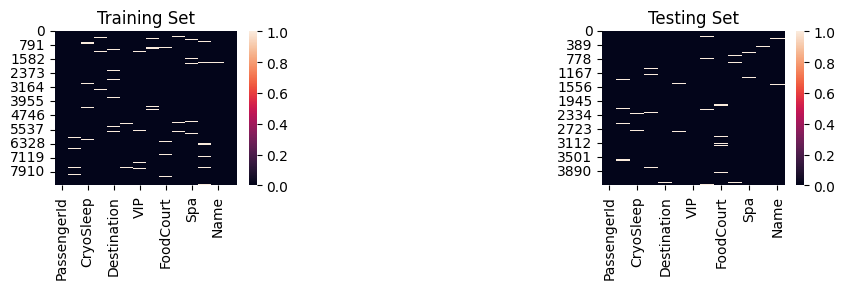

In [5]:
plt.figure(figsize = (10, 2))

plt.subplot(1, 3, 1)
plt.title("Training Set")
sns.heatmap(train.isnull())

plt.subplot(1, 3, 3)
plt.title("Testing Set")
sns.heatmap(test.isnull())
plt.show()

In [6]:
train

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


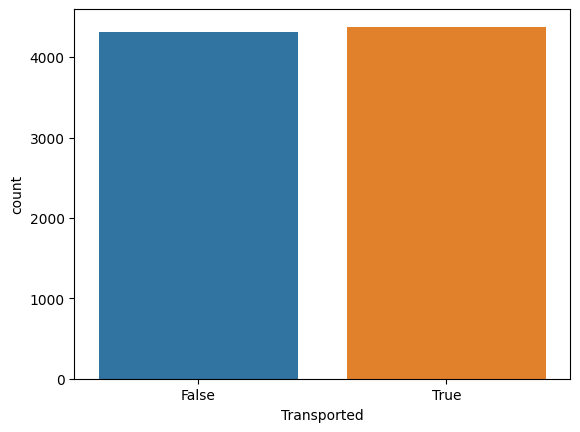

In [7]:
sns.countplot(x = train["Transported"])
plotter.xticks(rotation = 0);

In [8]:
X = train.drop(columns=['Transported'],axis=1)#drop
y = train["Transported"]

<a id="4"></a>
# **<center><span style="color:#005dc4;">Optuna</span></center>**

In [9]:
#optuna

#def objective(trial):
#    params = {
#        'random_seed':123,
#        'n_estimators'    :trial.suggest_int('n_estimators', 300, 1000),
#        'num_leaves'      :trial.suggest_int('num_leaves', 4, 32),
#        'max_depth'       :trial.suggest_int("max_depth",1,10),
#        'lambda'          : trial.suggest_loguniform("lambda", 1e-8, 1.0),
#        'subsample'       : trial.suggest_float("subsample", 0.01, 1.0, step = 0.1),   
#        'reg_lambda'      : trial.suggest_loguniform("lambda", 1e-8, 1.0),
#        'reg_alpha'       : trial.suggest_loguniform("alpha", 1e-8, 1.0)},
#        'colsample_bytree': trial.suggest_float("colsample_bytree", 0.1, 1.0, step = 0.1)   
            
#    model = xgb.XGBClassifier(**params)
#    model.fit(X,y)
#    y_pred = model.predict(X)
#    score = accuracy_score(y, y_pred)
    
#    return score

In [10]:
#study = optuna.create_study(sampler=optuna.samplers.RandomSampler(seed=123))
#study.optimize(objective, n_trials=50) 
#study.best_params

In [11]:
def get_score(model,X,y):
    n = cross_val_score(model,X,y,scoring ='accuracy',cv=10)
    return n

In [12]:
params_XGB_best ={'lambda': 3.06, 
             'alpha': 4.582, 
             'colsample_bytree': 0.93, 
             'subsample': 0.96, 
             'n_estimators': 725, 
             'max_depth': 5, 
             'learning_rate': 0.05    }

In [13]:
def t_fold(X,y,n_splits): 
    params= {'lambda': 3.06, 
             'alpha': 4.582, 
             'colsample_bytree': 0.93, 
             'subsample': 0.96, 
             'n_estimators': 7250, 
             'max_depth': 5, 
             'learning_rate': 0.05 ,
             'early_stopping_rounds':200,}
    results=[]
    n_iterations=[]
    skf = StratifiedKFold(n_splits=n_splits)
    for train_index, test_index in skf.split(X, y):
        train_X, valid_X = X.iloc[train_index], X.iloc[test_index]
        train_y, valid_y = y.iloc[train_index], y.iloc[test_index]
        model = xgb.XGBClassifier(**params).fit(train_X,train_y,
                                      eval_set=[(valid_X,valid_y)],
                                      verbose=0
                                     )  
        n_iteration = model.get_booster().best_iteration
        n_iterations.append(n_iteration)
        result = accuracy_score(valid_y,(model.predict(valid_X)))
        results.append(result)
        i=int(sum(n_iterations)/len(n_iterations))
    print("Average n_ite=" + str(i))
    print("% of scatter =" + str(np.std(n_iterations)/i))    
    n=sum(results)/len(results) 
    print (n)
    print("FIIINISH__________________________________\n")
    return n

<a id="5"></a>
# **<center><span style="color:#005dc4;">Preprocessing</span></center>**

In [14]:
train_test=train._append(test,ignore_index=True)

PassengerId        0
HomePlanet       288
CryoSleep        310
Cabin            299
Destination      274
Age              270
VIP              296
RoomService      263
FoodCourt        289
ShoppingMall     306
Spa              284
VRDeck           268
Name             294
Transported     4277
dtype: int64


<Axes: >

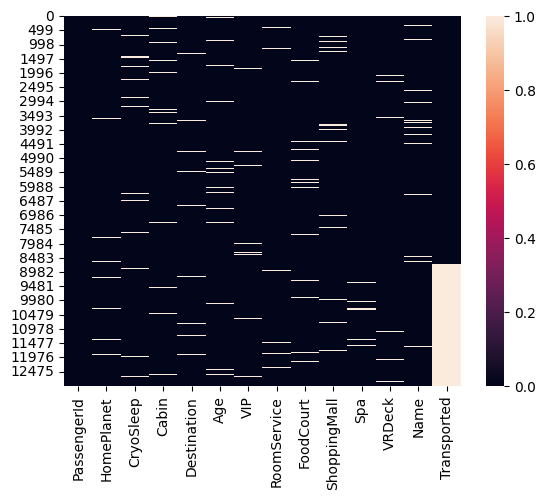

In [15]:
print(train_test.isnull().sum())
sns.heatmap(train_test.isnull())

# **<center><span style="color:#005dc4;">Expenses & CryoSleep</span></center>**

In [16]:
Expenses_columns = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']

In [17]:
train_test.loc[:,Expenses_columns]=train_test.apply(lambda x: 0 if x.CryoSleep == True else x,axis =1)

# **<center><span style="color:#005dc4;">CryoSleep & Expenses</span></center>**

In [18]:
train_test['Expenses'] = train_test.loc[:,Expenses_columns].sum(axis=1)

In [19]:
train_test.loc[:,['CryoSleep']]=train_test.apply(lambda x: True if x.Expenses == 0 and pd.isna(x.CryoSleep) else x,axis =1)

# **<center><span style="color:#005dc4;">N/A data</span></center>**

In [20]:
train_test.Name = train_test.Name.fillna('Unknown Unknown')

# **<center><span style="color:#005dc4;">Cabin process</span></center>**

In [21]:
train_test.loc[:,['Room']] = train_test.PassengerId.apply(lambda x: x[0:4] )

In [22]:
guide_VIP=train_test.loc[:,['Room','VIP']].dropna().drop_duplicates('Room')
guide_Cabin=train_test.loc[:,['Room','Cabin']].dropna().drop_duplicates('Room')
guide_HomePlanet=train_test.loc[:,['Room','HomePlanet']].dropna().drop_duplicates('Room')
guide_Destination=train_test.loc[:,['Room','Destination']].dropna().drop_duplicates('Room')
train_test=pd.merge(train_test,guide_Cabin,how="left",on='Room',suffixes=('','_y'))
train_test=pd.merge(train_test,guide_VIP,how="left",on='Room',suffixes=('','_y'))
train_test=pd.merge(train_test,guide_HomePlanet,how="left",on='Room',suffixes=('','_y'))
train_test=pd.merge(train_test,guide_Destination,how="left",on='Room',suffixes=('','_y'))

In [23]:
train_test.loc[:,['VIP']]=train_test.apply(lambda x: x.VIP_y if pd.isna(x.VIP) else x,axis=1)
train_test.loc[:,['Cabin']]=train_test.apply(lambda x:  x.Cabin_y if pd.isna(x.Cabin) else x,axis=1)
train_test.loc[:,['HomePlanet']]=train_test.apply(lambda x:  x.HomePlanet_y if pd.isna(x.HomePlanet) else x,axis=1)
train_test.loc[:,['Destination']]=train_test.apply(lambda x:  x.Destination_y if pd.isna(x.Destination) else x,axis=1)

In [24]:
train_test[train_test.Cabin.isnull()]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Expenses,Room,Cabin_y,VIP_y,HomePlanet_y,Destination_y
15,0012_01,Earth,False,NaN,TRAPPIST-1e,31.0,False,32.0,0.0,876.0,0.0,0.0,Justie Pooles,False,908.0,0012,NaN,False,Earth,TRAPPIST-1e
93,0101_01,Mars,True,NaN,TRAPPIST-1e,31.0,False,0.0,0.0,0.0,0.0,0.0,Book Trad,True,0.0,0101,NaN,False,Mars,TRAPPIST-1e
222,0239_01,Mars,False,NaN,TRAPPIST-1e,37.0,False,637.0,0.0,0.0,92.0,319.0,Diedow Resty,False,1048.0,0239,NaN,False,Mars,TRAPPIST-1e
272,0301_01,Earth,True,NaN,TRAPPIST-1e,16.0,False,0.0,0.0,0.0,0.0,0.0,Margia Wriggins,False,0.0,0301,NaN,False,Earth,TRAPPIST-1e
280,0310_01,Europa,False,NaN,TRAPPIST-1e,67.0,False,NaN,230.0,0.0,4476.0,241.0,Naviton Coudered,False,4947.0,0310,NaN,False,Europa,TRAPPIST-1e
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12869,9058_01,Mars,False,NaN,TRAPPIST-1e,38.0,NaN,784.0,0.0,42.0,38.0,10.0,Hammet Muff,NaN,874.0,9058,NaN,NaN,Mars,TRAPPIST-1e
12902,9138_01,Europa,NaN,NaN,TRAPPIST-1e,41.0,False,0.0,1998.0,0.0,1023.0,867.0,Misamak Trupistic,NaN,3888.0,9138,NaN,False,Europa,TRAPPIST-1e
12941,9223_01,Mars,True,NaN,TRAPPIST-1e,24.0,False,0.0,0.0,0.0,0.0,0.0,Weessh Sun,NaN,0.0,9223,NaN,False,Mars,TRAPPIST-1e
12942,9223_02,Mars,True,NaN,TRAPPIST-1e,17.0,False,0.0,0.0,0.0,0.0,0.0,Perit Sun,NaN,0.0,9223,NaN,False,Mars,TRAPPIST-1e


PassengerId         0
HomePlanet        157
CryoSleep         174
Cabin             162
Destination       154
Age               270
VIP               172
RoomService       170
FoodCourt         180
ShoppingMall      175
Spa               177
VRDeck            177
Name                0
Transported      4277
Expenses            0
Room                0
Cabin_y           162
VIP_y             172
HomePlanet_y      157
Destination_y     154
dtype: int64


<Axes: >

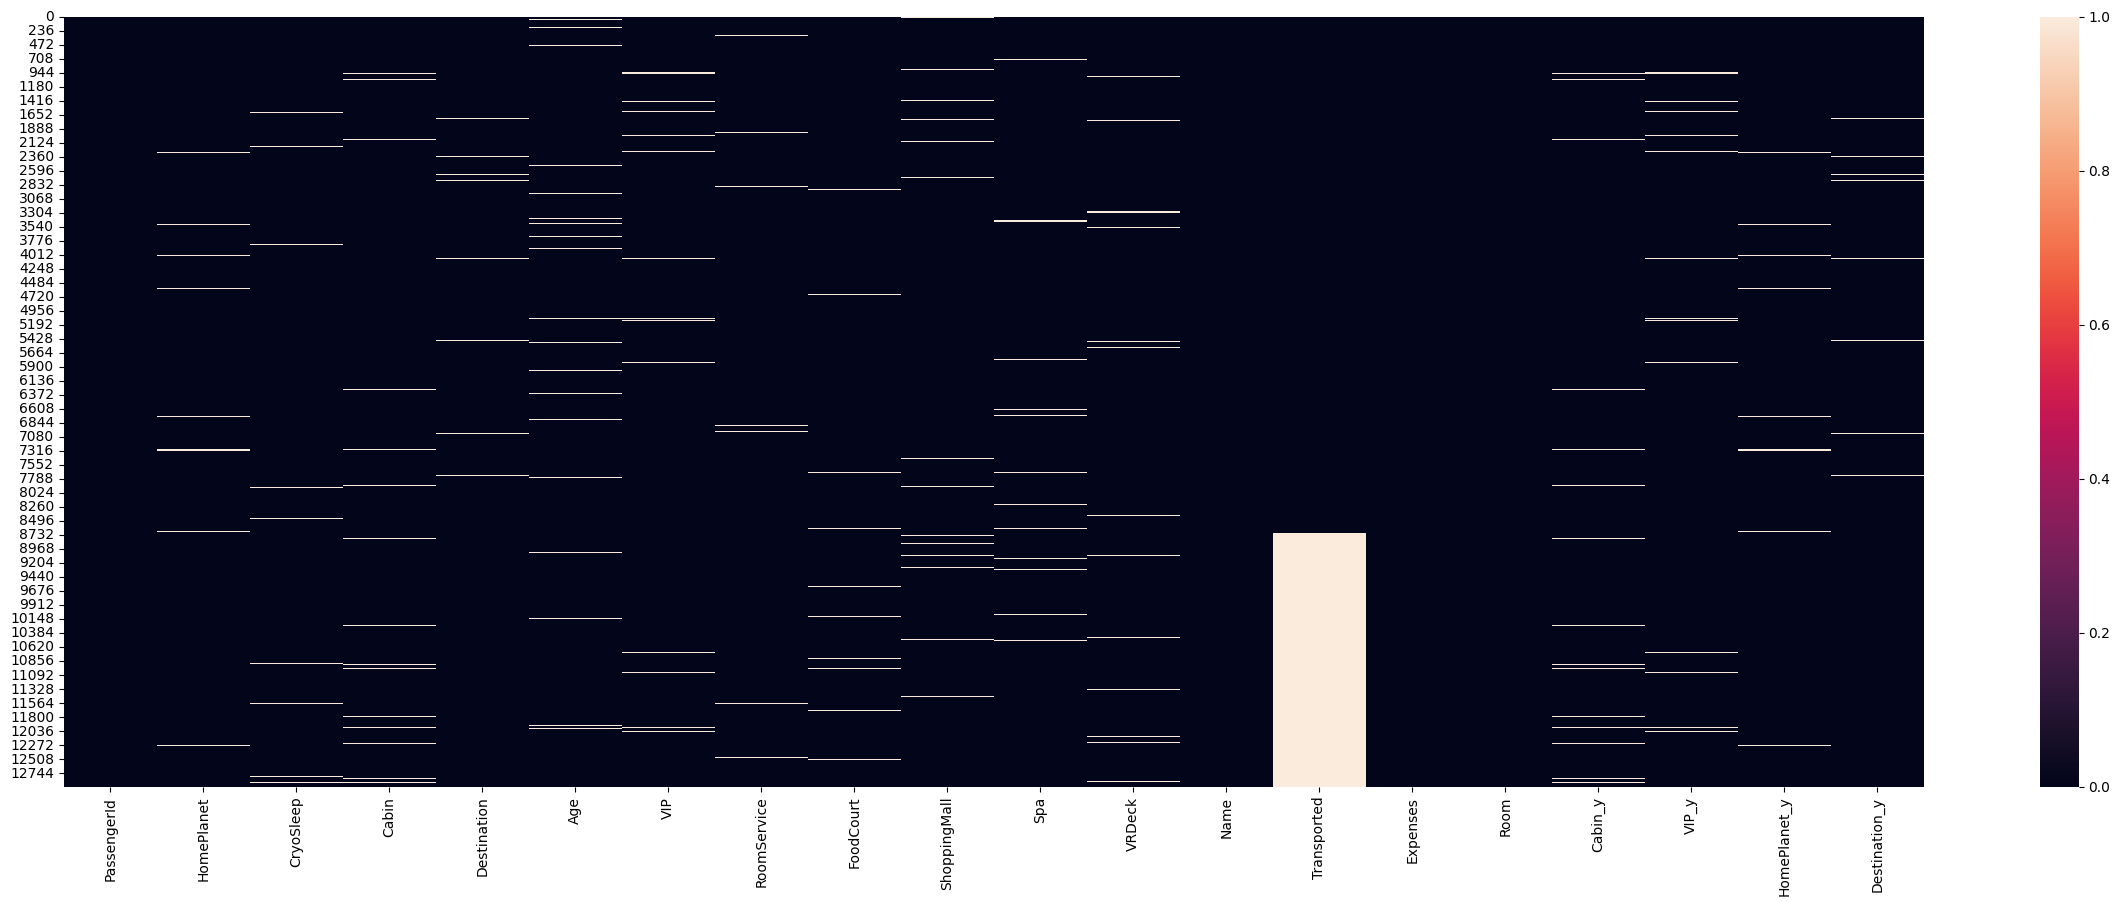

In [25]:
fig,ax = plt.subplots(figsize=(30,10))
pd.set_option('display.max_rows', 100)
print(train_test.isnull().sum())
sns.heatmap(train_test.isnull())

# **<center><span style="color:#005dc4;">Age process</span></center>**

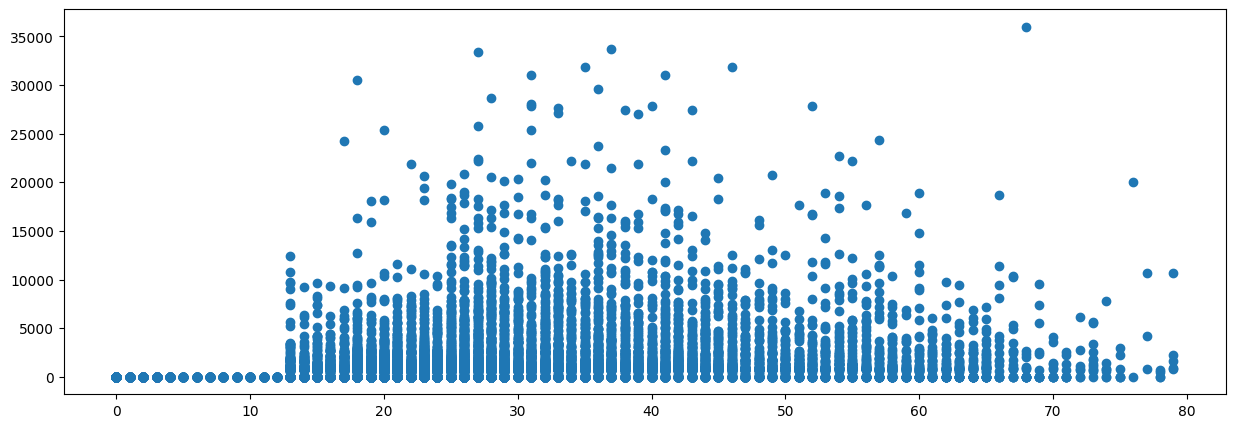

In [26]:
fig, ax = plt.subplots(figsize=(15,5))
analys = train_test.loc[:,['Age','Expenses']]
ax.scatter(analys.Age,analys.Expenses)

PassengerId         0
HomePlanet        157
CryoSleep         174
Cabin             162
Destination       154
Age               270
VIP               172
RoomService       170
FoodCourt         180
ShoppingMall      175
Spa               177
VRDeck            177
Name                0
Transported      4277
Expenses            0
Room                0
Cabin_y           162
VIP_y             172
HomePlanet_y      157
Destination_y     154
dtype: int64


<Axes: >

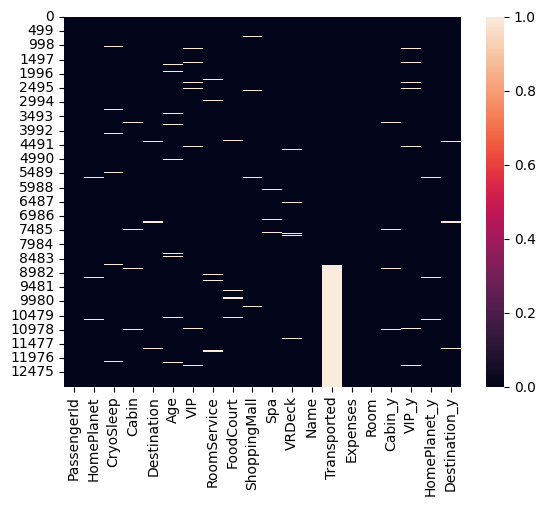

In [27]:
pd.set_option('display.max_rows', 100)
print(train_test.isnull().sum())
sns.heatmap(train_test.isnull())

# **<center><span style="color:#005dc4;">HomePlanet & Destination</span></center>**

In [28]:
analys = train_test.loc[:,['HomePlanet','Destination']]
analys['numeric'] =1
analys.groupby(['Destination','HomePlanet']).count()

numeric
Destination   HomePlanet         
55 Cancri e   Earth           995
              Europa         1343
              Mars            299
PSO J318.5-22 Earth          1083
              Europa           29
              Mars             68
TRAPPIST-1e   Earth          4737
              Europa         1780
              Mars           2328

PassengerId         0
HomePlanet        157
CryoSleep         174
Cabin             162
Destination       154
Age               270
VIP               172
RoomService       170
FoodCourt         180
ShoppingMall      175
Spa               177
VRDeck            177
Name                0
Transported      4277
Expenses            0
Room                0
Cabin_y           162
VIP_y             172
HomePlanet_y      157
Destination_y     154
dtype: int64


<Axes: >

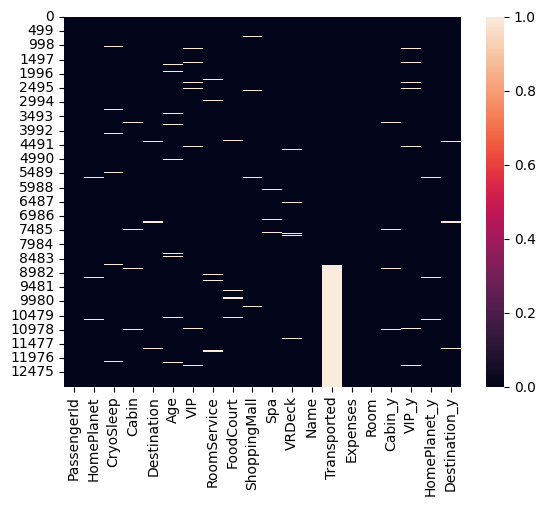

In [29]:
pd.set_option('display.max_rows', 100)
print(train_test.isnull().sum())
sns.heatmap(train_test.isnull())

# **<center><span style="color:#005dc4;">Split Cabin column</span></center>**

In [30]:
train_test.loc[:,['Cabin_1']] = train_test.Cabin.str.split("/",expand=True).iloc[:,0]
train_test.loc[:,['Cabin_2']] = train_test.Cabin.str.split("/",expand=True).iloc[:,1]
train_test.loc[:,['Cabin_3']] = train_test.Cabin.str.split("/",expand=True).iloc[:,2]
train_test

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Expenses,Room,Cabin_y,VIP_y,HomePlanet_y,Destination_y,Cabin_1,Cabin_2,Cabin_3
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,0.0,0001,B/0/P,False,Europa,TRAPPIST-1e,B,0,P
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,736.0,0002,F/0/S,False,Earth,TRAPPIST-1e,F,0,S
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,10383.0,0003,A/0/S,True,Europa,TRAPPIST-1e,A,0,S
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,5176.0,0003,A/0/S,True,Europa,TRAPPIST-1e,A,0,S
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,1091.0,0004,F/1/S,False,Earth,TRAPPIST-1e,F,1,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12965,9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,Jeron Peter,NaN,0.0,9266,F/1796/S,False,Earth,TRAPPIST-1e,G,1496,S
12966,9269_01,Earth,False,NaN,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,Matty Scheron,NaN,1018.0,9269,NaN,False,Earth,TRAPPIST-1e,NaN,None,None
12967,9271_01,Mars,True,D/296/P,55 Cancri e,NaN,False,0.0,0.0,0.0,0.0,0.0,Jayrin Pore,NaN,0.0,9271,D/296/P,False,Mars,55 Cancri e,D,296,P
12968,9273_01,Europa,False,D/297/P,NaN,NaN,False,0.0,2680.0,0.0,0.0,523.0,Kitakan Conale,NaN,3203.0,9273,D/297/P,False,Europa,NaN,D,297,P


In [31]:
train_test.loc[:,['FirstName']] = train_test.Name.str.split(" ",expand=True).iloc[:,0]
train_test.loc[:,['SecondName']] = train_test.Name.str.split(" ",expand=True).iloc[:,1]
train_test['Name_key']=train_test['SecondName']+train_test['Room']
train_test

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Expenses,Room,Cabin_y,VIP_y,HomePlanet_y,Destination_y,Cabin_1,Cabin_2,Cabin_3,FirstName,SecondName,Name_key
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,0.0,0001,B/0/P,False,Europa,TRAPPIST-1e,B,0,P,Maham,Ofracculy,Ofracculy0001
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,736.0,0002,F/0/S,False,Earth,TRAPPIST-1e,F,0,S,Juanna,Vines,Vines0002
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,10383.0,0003,A/0/S,True,Europa,TRAPPIST-1e,A,0,S,Altark,Susent,Susent0003
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,5176.0,0003,A/0/S,True,Europa,TRAPPIST-1e,A,0,S,Solam,Susent,Susent0003
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,1091.0,0004,F/1/S,False,Earth,TRAPPIST-1e,F,1,S,Willy,Santantines,Santantines0004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12965,9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,Jeron Peter,NaN,0.0,9266,F/1796/S,False,Earth,TRAPPIST-1e,G,1496,S,Jeron,Peter,Peter9266
12966,9269_01,Earth,False,NaN,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,Matty Scheron,NaN,1018.0,9269,NaN,False,Earth,TRAPPIST-1e,NaN,None,None,Matty,Scheron,Scheron9269
12967,9271_01,Mars,True,D/296/P,55 Cancri e,NaN,False,0.0,0.0,0.0,0.0,0.0,Jayrin Pore,NaN,0.0,9271,D/296/P,False,Mars,55 Cancri e,D,296,P,Jayrin,Pore,Pore9271
12968,9273_01,Europa,False,D/297/P,NaN,NaN,False,0.0,2680.0,0.0,0.0,523.0,Kitakan Conale,NaN,3203.0,9273,D/297/P,False,Europa,NaN,D,297,P,Kitakan,Conale,Conale9273


# **<center><span style="color:#005dc4;">SimpleImputer + OneHotEncoder</span></center>**

In [32]:
num_cols = ['ShoppingMall','FoodCourt','RoomService','Spa','VRDeck','Expenses','Age']
cat_cols = ['CryoSleep','Cabin_1','Cabin_3','VIP','HomePlanet','Destination']
transported=['Transported']
train_test = train_test[num_cols+cat_cols+transported].copy()

num_imp = SimpleImputer(strategy='mean')
cat_imp = SimpleImputer(strategy='most_frequent')
ohe = OneHotEncoder (handle_unknown='ignore',sparse = False)


train_test[num_cols] = pd.DataFrame(num_imp.fit_transform(train_test[num_cols]),columns=num_cols)
train_test[cat_cols] = pd.DataFrame(cat_imp.fit_transform(train_test[cat_cols]),columns=cat_cols)
temp_train = pd.DataFrame(ohe.fit_transform(train_test[cat_cols]),columns= ohe.get_feature_names_out())
train_test = train_test.drop(cat_cols,axis=1)
train_test = pd.concat([train_test,temp_train],axis=1)
train_test

,ShoppingMall,FoodCourt,RoomService,Spa,VRDeck,Expenses,Age,Transported,CryoSleep_False,CryoSleep_True,Cabin_1_A,Cabin_1_B,Cabin_1_C,Cabin_1_D,Cabin_1_E,Cabin_1_F,Cabin_1_G,Cabin_1_T,Cabin_3_P,Cabin_3_S,Cabin_3_None,VIP_False,VIP_True,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
0,0.0,0.0,0.0,0.0,0.0,0.0,39.000000,False,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,25.0,9.0,109.0,549.0,44.0,736.0,24.000000,True,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.0,3576.0,43.0,6715.0,49.0,10383.0,58.000000,False,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,371.0,1283.0,0.0,3329.0,193.0,5176.0,33.000000,False,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,151.0,70.0,303.0,565.0,2.0,1091.0,16.000000,True,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12965,0.0,0.0,0.0,0.0,0.0,0.0,34.000000,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
12966,17.0,847.0,0.0,10.0,144.0,1018.0,42.000000,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
12967,0.0,0.0,0.0,0.0,0.0,0.0,28.771969,NaN,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
12968,0.0,2680.0,0.0,0.0,523.0,3203.0,28.771969,NaN,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


# **<center><span style="color:#005dc4;">split train and test set</span></center>**

In [33]:
train = train_test[train_test['Transported'].notnull()].copy()
train.Transported =train.Transported.astype('int')
test = train_test[train_test['Transported'].isnull()].drop("Transported",axis=1)
display(train)
display(test)

,ShoppingMall,FoodCourt,RoomService,Spa,VRDeck,Expenses,Age,Transported,CryoSleep_False,CryoSleep_True,Cabin_1_A,Cabin_1_B,Cabin_1_C,Cabin_1_D,Cabin_1_E,Cabin_1_F,Cabin_1_G,Cabin_1_T,Cabin_3_P,Cabin_3_S,Cabin_3_None,VIP_False,VIP_True,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
0,0.0,0.0,0.0,0.0,0.0,0.0,39.0,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,25.0,9.0,109.0,549.0,44.0,736.0,24.0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.0,3576.0,43.0,6715.0,49.0,10383.0,58.0,0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,371.0,1283.0,0.0,3329.0,193.0,5176.0,33.0,0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,151.0,70.0,303.0,565.0,2.0,1091.0,16.0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,0.0,6819.0,0.0,1643.0,74.0,8536.0,41.0,0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
8689,0.0,0.0,0.0,0.0,0.0,0.0,18.0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
8690,1872.0,0.0,0.0,1.0,0.0,1873.0,26.0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
8691,0.0,1049.0,0.0,353.0,3235.0,4637.0,32.0,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


,ShoppingMall,FoodCourt,RoomService,Spa,VRDeck,Expenses,Age,CryoSleep_False,CryoSleep_True,Cabin_1_A,Cabin_1_B,Cabin_1_C,Cabin_1_D,Cabin_1_E,Cabin_1_F,Cabin_1_G,Cabin_1_T,Cabin_3_P,Cabin_3_S,Cabin_3_None,VIP_False,VIP_True,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
8693,0.0,0.0,0.0,0.0,0.0,0.0,27.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
8694,0.0,9.0,0.0,2823.0,0.0,2832.0,19.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
8695,0.0,0.0,0.0,0.0,0.0,0.0,31.000000,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
8696,0.0,6652.0,0.0,181.0,585.0,7418.0,38.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
8697,635.0,0.0,10.0,0.0,0.0,645.0,20.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12965,0.0,0.0,0.0,0.0,0.0,0.0,34.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
12966,17.0,847.0,0.0,10.0,144.0,1018.0,42.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
12967,0.0,0.0,0.0,0.0,0.0,0.0,28.771969,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
12968,0.0,2680.0,0.0,0.0,523.0,3203.0,28.771969,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [34]:
X = train.drop('Transported',axis=1)
y = train.Transported

In [35]:
X,y = shuffle(X,y)
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

In [36]:
print(get_score(xgb.XGBClassifier(**params_XGB_best),X,y).mean())

0.8062824226551856


# **<center><span style="color:#005dc4;">Outliers</span></center>**

In [37]:
features_isolation =['ShoppingMall','FoodCourt','RoomService','Spa','VRDeck','Age']

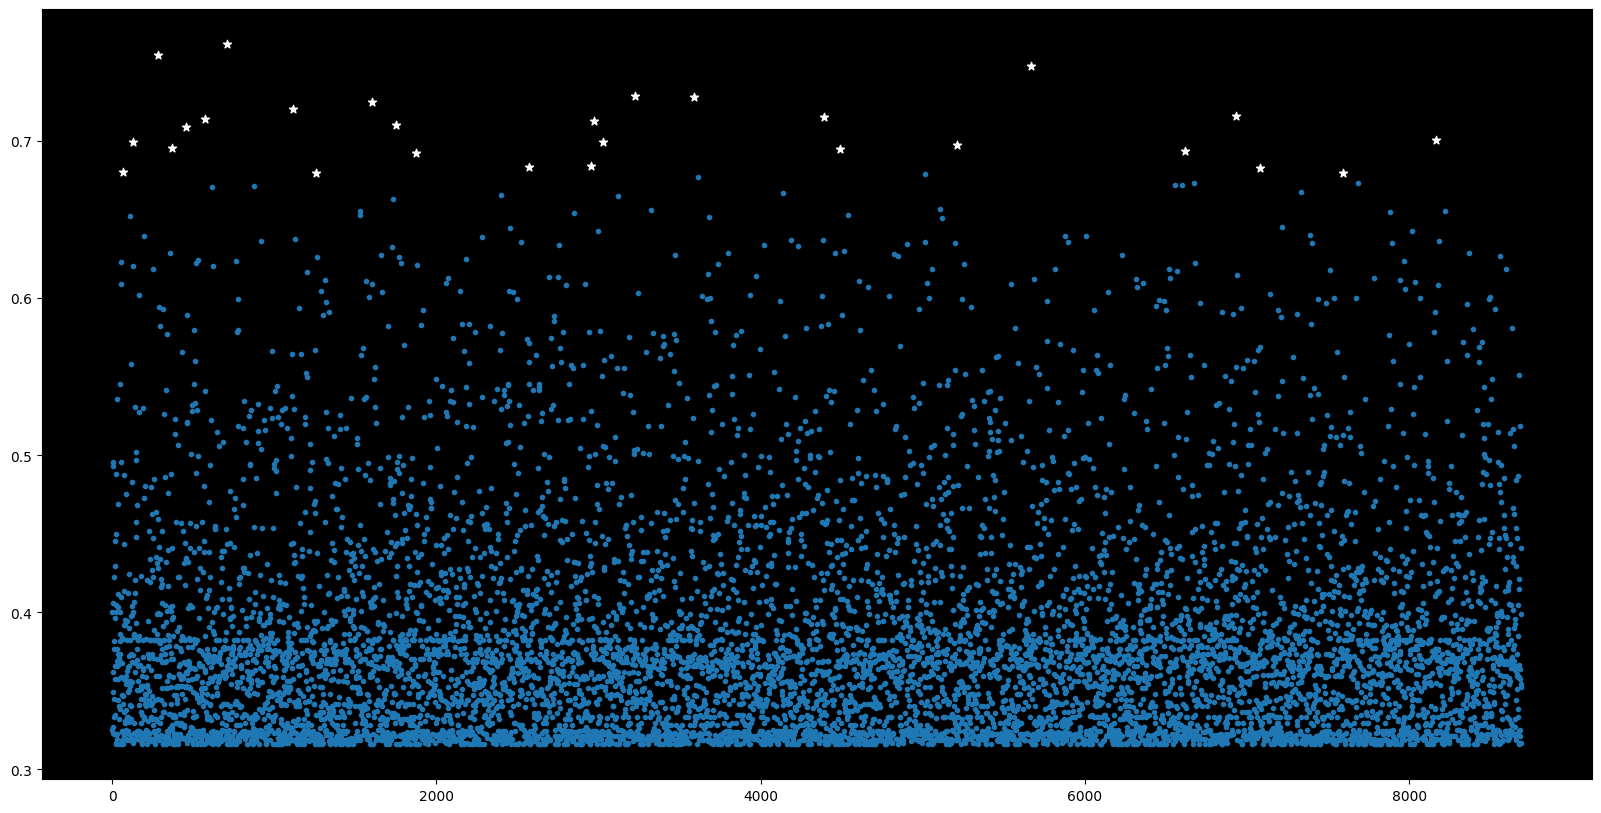

In [38]:
from sklearn.ensemble import IsolationForest

isf = IsolationForest(n_jobs=-1, random_state=1,n_estimators=100,contamination=0.003)
isf.fit(X[features_isolation], y)

rows = pd.DataFrame(isf.predict(X[features_isolation]),columns=['feature'])
rows_ind = rows[rows.feature == 1]
results = pd.DataFrame()
results['results'] = - isf.score_samples(X[features_isolation])
results['chance'] = isf.decision_function(X[features_isolation])
results['yes/no'] = isf.predict(X[features_isolation])

new = results[results['yes/no']==1]
old= results[results['yes/no']==-1]
fig,ax = plt.subplots(figsize=(20,10))
ax.set_facecolor('black')
ax = plt.scatter(new.index,new.results,marker=".")
ax = plt.scatter(old.index,old.results,color='white',marker="*")


In [39]:
X_1 = X.iloc[rows_ind.index].reset_index(drop=True)
y_1 = y.iloc[rows_ind.index].reset_index(drop=True) 

In [40]:
print(get_score(xgb.XGBClassifier(**params_XGB_best),X_1,y_1).mean())

0.8032548327033572


In [41]:
drop_list=['ShoppingMall','Age','CryoSleep_True','HomePlanet_Earth','HomePlanet_Europa',
'VIP_True','HomePlanet_Mars','Destination_PSO J318.5-22','VIP_False',
'Destination_55 Cancri e','FoodCourt','Destination_TRAPPIST-1e']

In [42]:
X=X.drop(drop_list,axis=1)
test=test.drop(drop_list,axis=1)

In [43]:
print(get_score(xgb.XGBClassifier(**params_XGB_best),X,y).mean())

0.8068568707590968


<a id="6"></a>
# **<center><span style="color:#005dc4;">KMeansSMOTE</span></center>**

In [44]:
from imblearn.over_sampling import KMeansSMOTE
sm = KMeansSMOTE(sampling_strategy=1, n_jobs=-1)
X_sm, y_sm = sm.fit_resample(X, y)
X = X_sm
y = y_sm

In [45]:
y.value_counts()

Transported
0    4384
1    4378
Name: count, dtype: int64

<a id="7"></a>
# **<center><span style="color:#005dc4;">Predict</span></center>**

In [46]:
pred_XGB = (xgb.XGBClassifier(**params_XGB_best).fit(X,y)).predict(test)
pred_XGB

array([1, 0, 1, ..., 1, 1, 1])

<a id="8"></a>
# **<center><span style="color:#005dc4;">Submission</span></center>**

In [47]:
Submission = pd.read_csv('/kaggle/input/spaceship-titanic/sample_submission.csv')
Submission

,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,False
3,0021_01,False
4,0023_01,False
...,...,...
4272,9266_02,False
4273,9269_01,False
4274,9271_01,False
4275,9273_01,False


In [48]:
Submission['Transported'] = pred_XGB
Submission

,PassengerId,Transported
0,0013_01,1
1,0018_01,0
2,0019_01,1
3,0021_01,1
4,0023_01,1
...,...,...
4272,9266_02,1
4273,9269_01,0
4274,9271_01,1
4275,9273_01,1


In [49]:
#1/0 → TRUE/FALSE
Submission['Transported']=Submission['Transported']>0.5
Submission.to_csv('Submission_XGB.csv', index=False)
Submission

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
...,...,...
4272,9266_02,True
4273,9269_01,False
4274,9271_01,True
4275,9273_01,True


<div class="alert alert-block alert-info" style="font-size:20px; background-color: #E4FFFF; font-family:verdana; color: #000115; border: 1px #000115 solid">
 I'm a beginner in the python world, not in undergrad or for work,just interest, and I'm still learning a lot of different ways to do it. I hope you'll give me your vote as well as comments to help me improve in the future, thanks!    Mr.Tao